# **Linear regression – main engine**

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import LinearRegression

In [ ]:
# Pre-processed data preparation
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

In [ ]:
# Optional time-flow column (negligible difference)
TrainingDataFrame["Time_flow"] = np.arange(1, len(TrainingDataFrame)+1)
historic_columns.append("Time_flow")

# **Linear regression – engine**

In [ ]:
# To track how well predictions work, all metrics -> dominance, MAPE/APE and benchmark performance
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    # Bounded training-validation set
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    # Previously optimized
    training_length = 4 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    # Rolling windows for single stock
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = LinearRegression()

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))

        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        


        #print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))
    
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()
    model_dominance[ticker] = dominance_dates.copy()

In [5]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [ ]:
# MAPE in average
print(np.mean(list(mean_performances.values())))

np.float64(1.8439090880320828)

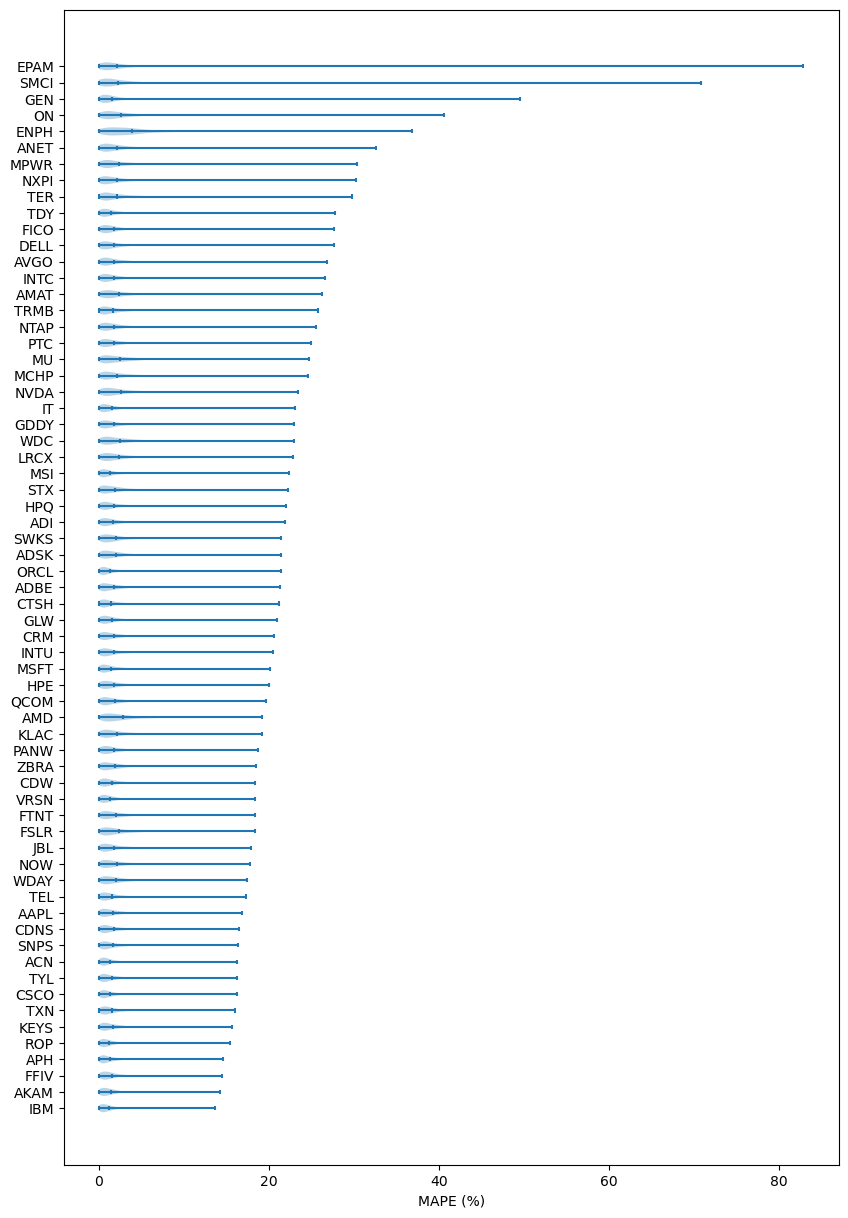

In [8]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("MAPE (%)")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.show()

In [8]:
mean_performances

{'IBM': np.float64(1.225113265417369),
 'ROP': np.float64(1.2326994165954013),
 'ACN': np.float64(1.2881919953701761),
 'ORCL': np.float64(1.2966011590669912),
 'APH': np.float64(1.305984557936524),
 'CSCO': np.float64(1.3261515255691991),
 'VRSN': np.float64(1.3445666787173756),
 'MSI': np.float64(1.3497156599140414),
 'CTSH': np.float64(1.3860717108161547),
 'AKAM': np.float64(1.397834677920866),
 'TDY': np.float64(1.4550193024483726),
 'MSFT': np.float64(1.4673234236798622),
 'TYL': np.float64(1.4791124595811278),
 'TEL': np.float64(1.4867538674759906),
 'IT': np.float64(1.494976877786637),
 'CDW': np.float64(1.5143932249028598),
 'FFIV': np.float64(1.5236975271224908),
 'GEN': np.float64(1.535298552427128),
 'GLW': np.float64(1.5591693360999177),
 'TXN': np.float64(1.5831510745715534),
 'AAPL': np.float64(1.602696394554027),
 'KEYS': np.float64(1.613065848191751),
 'SNPS': np.float64(1.6482871379599457),
 'ADI': np.float64(1.6832411354877228),
 'TRMB': np.float64(1.7076635198865713

In [ ]:
# Dominance in average
print(np.mean([np.mean(i) for i in performance_simple.values()]))

np.float64(0.4481696014828545)

# **Date-wise model dominance over naive**

Dominance of model in single rolling windows was analyzed. Particularly, we analyzed how well model performed in time for chosen stocks. Even though this analysis was not included in the final thesis text, we decided to leave it in the source codes.

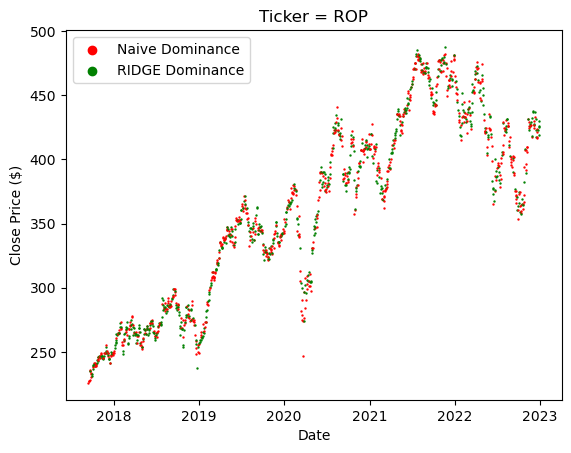

In [10]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ROP"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

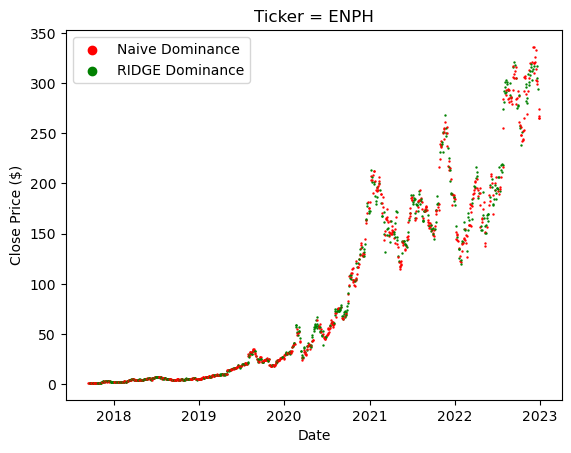

In [11]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ENPH"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

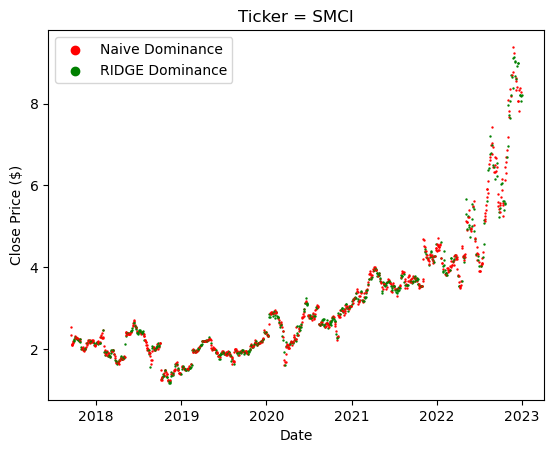

In [12]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "SMCI"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

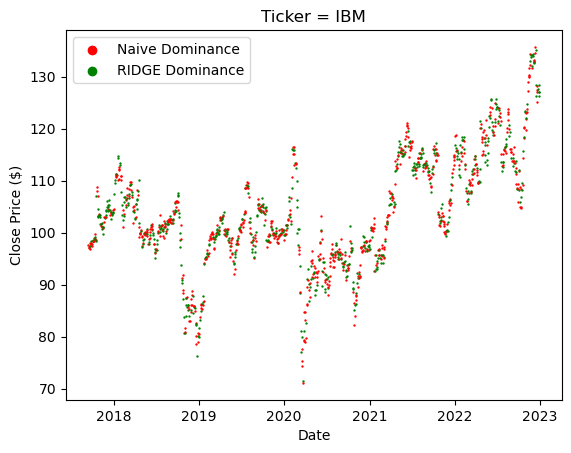

In [13]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "IBM"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

# **Analysis of dominance in detail**

Apart from the analysis of performance in the whole time interval, we analyzed performance of models in major event on the market during the analyzed period. 

We analyzed COVID-19 period and Trump tarrifs, but nothing in particular was found.

In [14]:
# COVID
# We perform analysis of precision between February and March 2020 -> Covid recession

# Number of trading days -> 41 days
trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= "2020-02-01") & (TrainingDataFrame["Date"] <= "2020-03-31")]["Date"].values
trading_days = [str(i).split("T")[0] for i in trading_days]

covid_dominances = {}

for ticker in tickers["Ticker"]:
    counter = 0
    for day in model_dominance[ticker]:
        if day in trading_days:
            counter += 1
    covid_dominances[ticker] = counter*100 / len(trading_days)

print(np.mean(list(covid_dominances.values())))

40.825515947467174


In [15]:
sorted(covid_dominances.items(), key=lambda x: x[1], reverse=True)

[('JBL', 53.65853658536585),
 ('ENPH', 51.21951219512195),
 ('APH', 48.78048780487805),
 ('DELL', 48.78048780487805),
 ('IT', 48.78048780487805),
 ('IBM', 48.78048780487805),
 ('NXPI', 48.78048780487805),
 ('SWKS', 48.78048780487805),
 ('SMCI', 48.78048780487805),
 ('AVGO', 46.34146341463415),
 ('HPQ', 46.34146341463415),
 ('NTAP', 46.34146341463415),
 ('PANW', 46.34146341463415),
 ('PTC', 46.34146341463415),
 ('CRM', 46.34146341463415),
 ('VRSN', 46.34146341463415),
 ('WDC', 46.34146341463415),
 ('FFIV', 43.90243902439025),
 ('FICO', 43.90243902439025),
 ('GDDY', 43.90243902439025),
 ('HPE', 43.90243902439025),
 ('MU', 43.90243902439025),
 ('MSFT', 43.90243902439025),
 ('ORCL', 43.90243902439025),
 ('TEL', 43.90243902439025),
 ('TDY', 43.90243902439025),
 ('TRMB', 43.90243902439025),
 ('TYL', 43.90243902439025),
 ('WDAY', 43.90243902439025),
 ('AKAM', 41.46341463414634),
 ('CTSH', 41.46341463414634),
 ('FSLR', 41.46341463414634),
 ('MCHP', 41.46341463414634),
 ('MSI', 41.4634146341463

In [16]:
# Trumpove mecheche
# We perform analysis of precision between of April 2025 -> Trump's tarrifs

# Number of trading days
trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= "2025-04-01") & (TrainingDataFrame["Date"] <= "2025-04-30")]["Date"].values
trading_days = [str(i).split("T")[0] for i in trading_days]

trump_dominances = {}

for ticker in tickers["Ticker"]:
    counter = 0
    for day in model_dominance[ticker]:
        if day in trading_days:
            counter += 1
    trump_dominances[ticker] = counter*100 / len(trading_days)

print(np.mean(list(trump_dominances.values())))

0.0


In [17]:
sorted(trump_dominances.items(), key=lambda x: x[1], reverse=True)

[('ACN', 0.0),
 ('ADBE', 0.0),
 ('AMD', 0.0),
 ('AKAM', 0.0),
 ('APH', 0.0),
 ('ADI', 0.0),
 ('AAPL', 0.0),
 ('AMAT', 0.0),
 ('ANET', 0.0),
 ('ADSK', 0.0),
 ('AVGO', 0.0),
 ('CDNS', 0.0),
 ('CDW', 0.0),
 ('CSCO', 0.0),
 ('CTSH', 0.0),
 ('GLW', 0.0),
 ('DELL', 0.0),
 ('ENPH', 0.0),
 ('EPAM', 0.0),
 ('FFIV', 0.0),
 ('FICO', 0.0),
 ('FSLR', 0.0),
 ('FTNT', 0.0),
 ('IT', 0.0),
 ('GEN', 0.0),
 ('GDDY', 0.0),
 ('HPE', 0.0),
 ('HPQ', 0.0),
 ('IBM', 0.0),
 ('INTC', 0.0),
 ('INTU', 0.0),
 ('JBL', 0.0),
 ('KEYS', 0.0),
 ('KLAC', 0.0),
 ('LRCX', 0.0),
 ('MCHP', 0.0),
 ('MU', 0.0),
 ('MSFT', 0.0),
 ('MPWR', 0.0),
 ('MSI', 0.0),
 ('NTAP', 0.0),
 ('NVDA', 0.0),
 ('NXPI', 0.0),
 ('ON', 0.0),
 ('ORCL', 0.0),
 ('PANW', 0.0),
 ('PTC', 0.0),
 ('QCOM', 0.0),
 ('ROP', 0.0),
 ('CRM', 0.0),
 ('STX', 0.0),
 ('NOW', 0.0),
 ('SWKS', 0.0),
 ('SMCI', 0.0),
 ('SNPS', 0.0),
 ('TEL', 0.0),
 ('TDY', 0.0),
 ('TER', 0.0),
 ('TXN', 0.0),
 ('TRMB', 0.0),
 ('TYL', 0.0),
 ('VRSN', 0.0),
 ('WDC', 0.0),
 ('WDAY', 0.0),
 ('ZB

Lastly, dominance per single year is depicted. This shows rather stability of the model during the periods.

In [18]:
years = [str(i) for i in range(2017, 2023)]
dominances = []

for year in years:
    trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= f"{year}-01-01") & (TrainingDataFrame["Date"] <= f"{year}-12-31")]["Date"].values
    trading_days = [str(i).split("T")[0] for i in trading_days]

    year_dominances = {}

    for ticker in tickers["Ticker"]:
        counter = 0
        for day in model_dominance[ticker]:
            if day in trading_days:
                counter += 1
        year_dominances[ticker] = counter*100 / len(trading_days)

    dominances.append(np.mean(list(year_dominances.values())))
    print(year, np.mean(list(year_dominances.values())))

2017 42.3076923076923
2018 46.25804474410052
2019 45.31746031746032
2020 43.78838552751597
2021 44.328449328449324
2022 44.24762488507508


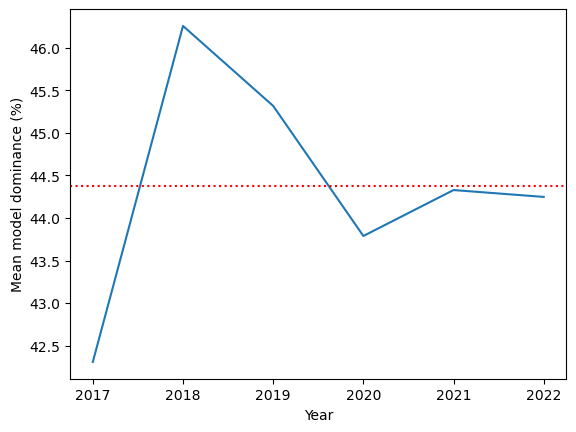

In [19]:
plt.plot(years, dominances)

plt.xlabel("Year")
plt.ylabel("Mean model dominance (%)")

plt.axhline(np.mean(dominances), linestyle="dotted", color="red")

plt.show()